Important Library

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report

In [2]:
DATA_FILE = Path("/content/vibration_dataset.csv").with_name("vibration_dataset.csv")
# WINDOW_LENGTH = 256

Load and understand the data

In [3]:
df = pd.read_csv(DATA_FILE)
print("\n--- Dataset overview ---")
print("Shape:", df.shape)
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass counts:\n", df.groupby("window_id")["fault"].first().value_counts())


--- Dataset overview ---
Shape: (51200, 6)
     window_id  sample_index    time_s  vibration  sampling_rate_hz    fault
0  Healthy_000             0  0.000000  -0.863890             12000  Healthy
1  Healthy_000             1  0.000083  -0.799609             12000  Healthy
2  Healthy_000             2  0.000167  -0.654381             12000  Healthy
3  Healthy_000             3  0.000250  -0.693713             12000  Healthy
4  Healthy_000             4  0.000333  -0.655845             12000  Healthy

Data types:
 window_id            object
sample_index          int64
time_s              float64
vibration           float64
sampling_rate_hz      int64
fault                object
dtype: object

Missing values:
 window_id           0
sample_index        0
time_s              0
vibration           0
sampling_rate_hz    0
fault               0
dtype: int64

Class counts:
 fault
Ball_Fault          50
Healthy             50
Inner_Race_Fault    50
Outer_Race_Fault    50
Name: count, dtype: i

Extract statistical features for every window

In [4]:
def extract_features(signal):
    """Return common time-domain statistical features for one signal window."""
    signal = np.asarray(signal, dtype=float)
    abs_signal = np.abs(signal)
    mean_abs = np.mean(abs_signal)
    rms = np.sqrt(np.mean(signal ** 2))
    peak = np.max(abs_signal)
    return {
        "mean": np.mean(signal),
        "variance": np.var(signal, ddof=1),
        "std": np.std(signal, ddof=1),
        "rms": rms,
        "skewness": skew(signal, bias=False),
        "kurtosis": kurtosis(signal, fisher=False, bias=False),
        "peak_to_peak": np.ptp(signal),
        "crest_factor": peak / (rms + 1e-12),
        "shape_factor": rms / (mean_abs + 1e-12),
    }

feature_rows = []
for window_id, group in df.groupby("window_id", sort=True):
    group = group.sort_values("sample_index")
    signal = group["vibration"].to_numpy()
    row = extract_features(signal)
    row["window_id"] = window_id
    row["fault"] = group["fault"].iloc[0]
    feature_rows.append(row)

features = pd.DataFrame(feature_rows)
features.to_csv("vibration_features.csv", index=False)
print("\n--- Extracted feature table ---")
print(features.head())
print("Feature table saved as vibration_features.csv")
print("\nFeature table shape:", features.shape)

feature_cols = [
    "mean", "variance", "std", "rms", "skewness", "kurtosis",
    "peak_to_peak", "crest_factor", "shape_factor"
]
X = features[feature_cols]
y = features["fault"]


--- Extracted feature table ---
       mean  variance       std       rms  skewness  kurtosis  peak_to_peak  \
0  0.015418  0.244861  0.494835  0.494108  0.102895  2.211922      2.380919   
1 -0.010736  0.216164  0.464934  0.464150 -0.210455  2.340677      2.256461   
2  0.032939  0.239049  0.488926  0.489081  0.197299  2.045267      2.289574   
3  0.015170  0.213971  0.462570  0.461914  0.217381  2.302246      2.299556   
4 -0.000929  0.192300  0.438521  0.437664 -0.510762  2.205085      1.937481   

   crest_factor  shape_factor       window_id       fault  
0      2.505225      1.183052  Ball_Fault_000  Ball_Fault  
1      2.445586      1.214891  Ball_Fault_001  Ball_Fault  
2      2.367080      1.177133  Ball_Fault_002  Ball_Fault  
3      2.762449      1.196224  Ball_Fault_003  Ball_Fault  
4      2.638441      1.173638  Ball_Fault_004  Ball_Fault  
Feature table saved as vibration_features.csv

Feature table shape: (200, 11)


Exploratory feature plots

<Figure size 800x400 with 0 Axes>

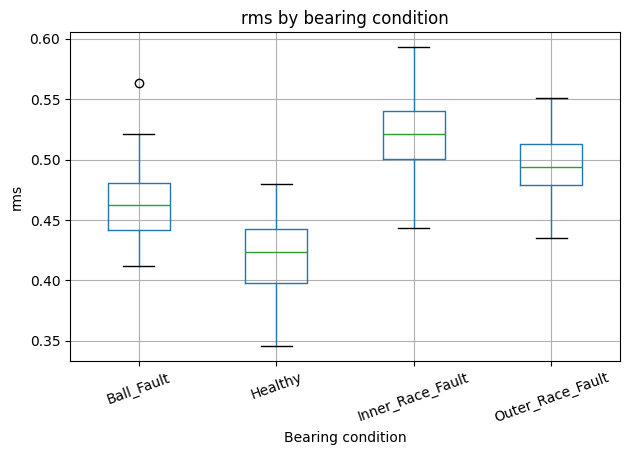

<Figure size 800x400 with 0 Axes>

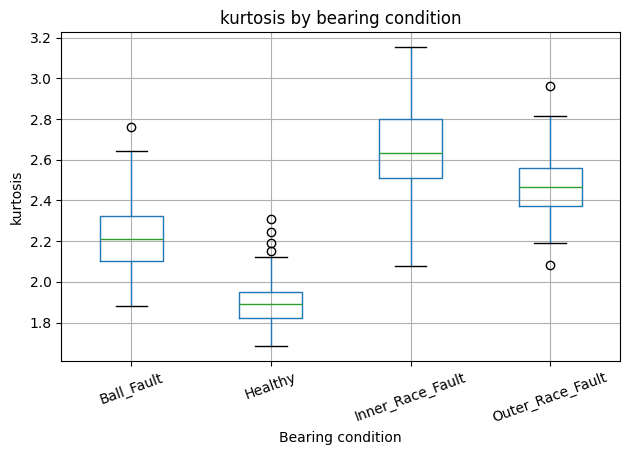

<Figure size 800x400 with 0 Axes>

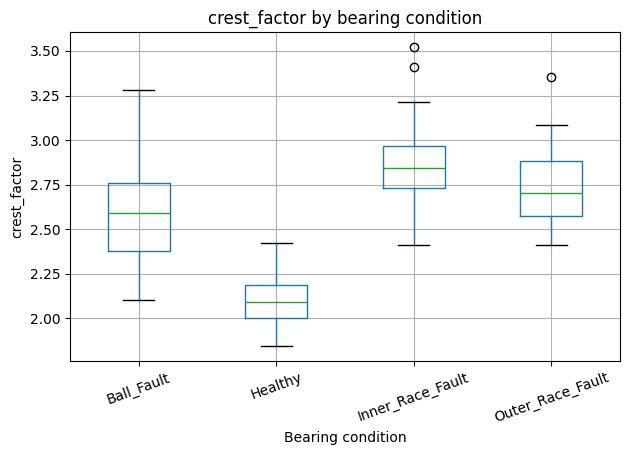

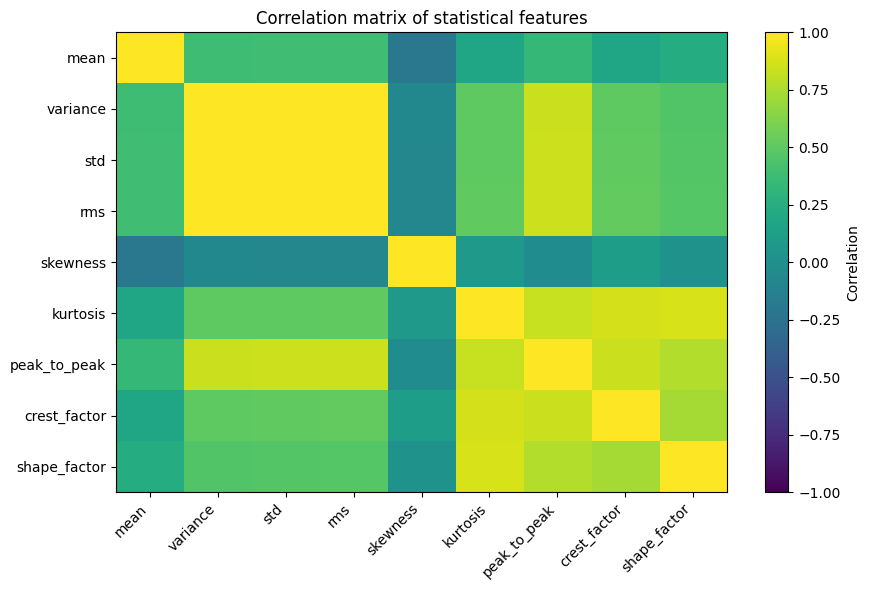

In [5]:
for col in ["rms", "kurtosis", "crest_factor"]:
    plt.figure(figsize=(8, 4))
    features.boxplot(column=col, by="fault", rot=20)
    plt.title(f"{col} by bearing condition")
    plt.suptitle("")
    plt.xlabel("Bearing condition")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Correlation matrix
plt.figure(figsize=(9, 6))
corr = features[feature_cols].corr()
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha="right")
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Correlation matrix of statistical features")
plt.tight_layout()
plt.show()

Encode labels, split data, and scale features

In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split by window: each window is one independent row in the feature table.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

PCA: feature extraction


--- PCA explained variance ---
PC1: 0.5970 (59.70%)
PC2: 0.1777 (17.77%)
PC3: 0.1022 (10.22%)
Cumulative explained variance: 0.8769


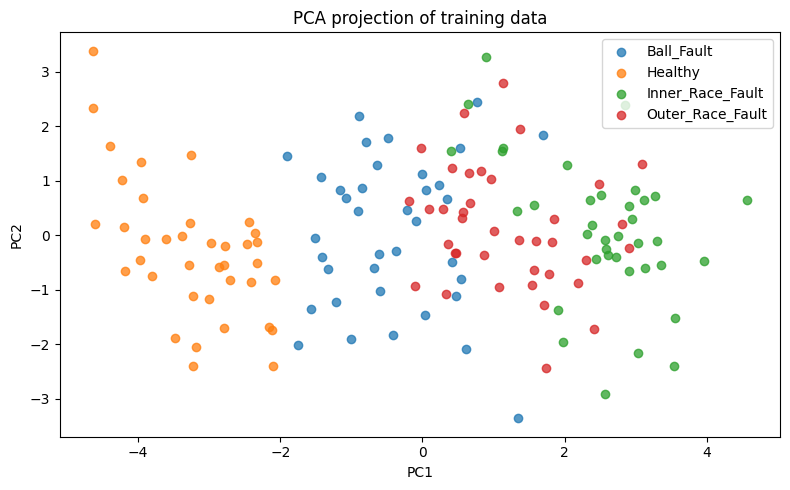

In [7]:
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\n--- PCA explained variance ---")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")
print("Cumulative explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 5))
for class_name in np.unique(y_train):
    mask = y_train == class_name
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=label_encoder.inverse_transform([class_name])[0], alpha=0.75)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of training data")
plt.legend()
plt.tight_layout()
plt.show()

Feature selection: Random Forest feature importance


--- Random Forest Feature Importance ---
     feature  feature_importance
peak_to_peak            0.278913
    kurtosis            0.157201
crest_factor            0.134839
shape_factor            0.087875
         rms            0.082121
    variance            0.075039
         std            0.073441
    skewness            0.060811
        mean            0.049761
Selected features: ['peak_to_peak', 'kurtosis', 'crest_factor']


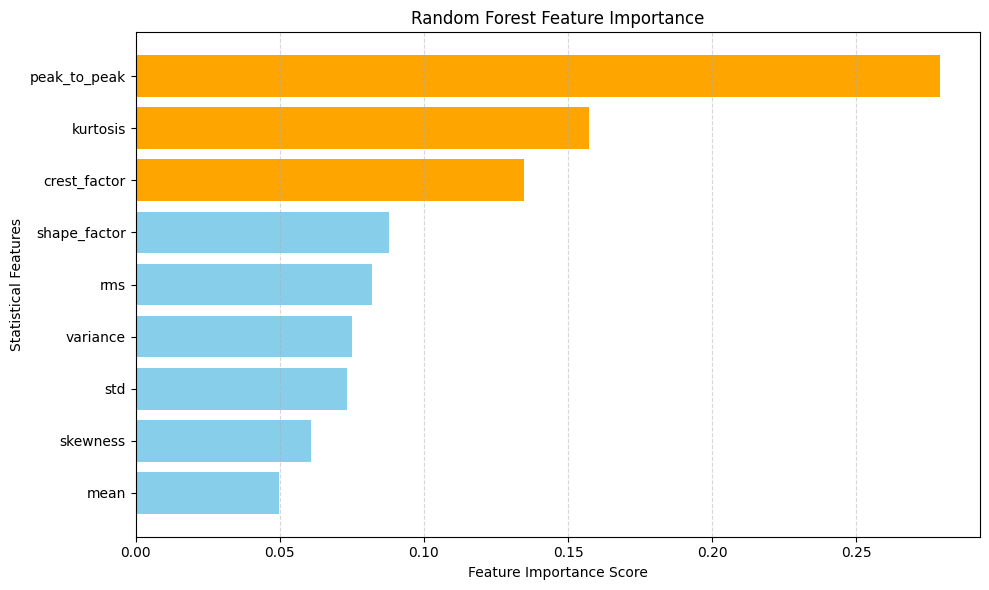

In [8]:
selection_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

selection_model.fit(X_train_scaled, y_train)

importance_scores = pd.DataFrame({
    "feature": feature_cols,
    "feature_importance": selection_model.feature_importances_
}).sort_values("feature_importance", ascending=False)

# Select the three most important features
selected_features = importance_scores.head(3)["feature"].to_numpy()

selected_indices = [
    feature_cols.index(feature)
    for feature in selected_features
]

X_train_selected = X_train_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]

print("\n--- Random Forest Feature Importance ---")
print(importance_scores.to_string(index=False))
print("Selected features:", list(selected_features))

plt.figure(figsize=(10, 6))

colors = [
    "orange" if feature in selected_features else "skyblue"
    for feature in importance_scores["feature"]
]

plt.barh(
    importance_scores["feature"],
    importance_scores["feature_importance"],
    color=colors
)

plt.xlabel("Feature Importance Score")
plt.ylabel("Statistical Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

